## 005_backtest — Leader–Follower Strategy Validation

**Author:** Wayne Kirk Schmidt

**Email:** wayne.kirk.schmidt@gmail.com

---

## Stage Purpose

This stage evaluates the hypotheses identified in **004_strategy** by constructing and testing trade rules based on
leader–follower shock propagation.

Using the event-level response structure produced in 004, we simulate trades that exploit delayed reactions between assets and measure
the resulting performance characteristics.

The goal of this stage is **validation** to see if the results we found in 004 can be translated into a trading strategy.

## Inputs

Loaded from the pipeline manifest:

* `event_response_expanded.pkl` *(from 004_strategy)*
* Event-level leader–follower response dataset
* Includes:
    * reference coin (`r_coin`)
    * follower coin (`f_coin`)
    * shock magnitude (`sigma`)
    * forward returns (`lag_1` … `lag_N`)

Additional inputs:

* `returns_full.pkl` *(from 002_enrich)* - Daily return series for all assets
* `price_wide.pkl` *(from 002_enrich, optional)* - Wide-format price series (diagnostic / validation use only)

## Outputs 

Persisted in `output/005_backtest/`

* `trade_df.pkl`
* `daily_returns.pkl`
* `equity_curve.pkl`
* `performance_summary.pkl`
* `stress_summary.pkl`

All outputs are registered in the pipeline `manifest.pkl`.

## Tasks

This notebook performs the following steps:

1. **Signal Construction** from saved information
2. **Trade Construction** looking at t+n from our returns file
3. **Trade Simulation** run through 20 to 40 bps and note we have a holding time of 1 day
4. **Performance Evaluation** via Sharpe, Drawdown, hit rate fulfilling the requirements document
5. **Robustness Test** look at the number of elements versus population
6. **Assessment** describe the hypothesis and evaluate of we have a trading strategy or not

## Notes
- This stage operates exclusively on persisted artifacts from **004_strategy** and **002_enrich**.
- All derived datasets (filtered / strong subsets) are constructed within this notebook and are not treated as pipeline inputs.

## Pipeline Position

- 001_download --> data acquisition
- 002_enrich --> transformation and enrichment
- 003_analysis --> statistical structure  
- 004_strategy --> exploration and hypothesis evaluation
- **005_backtest --> execution mapping and performance evaluation**

## Design Principles

- **Deterministic pipeline** — no recomputation of prior stages
- **No forward assumptions** — all results derived from observed data
- **Separation from backtesting** — evaluation only, not deployment
- **Full artifact persistence** — every transformation is saved



### 1. Imports and Environment Setup
### Provide the necessary imports required for to to proceed.   

In [155]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime, UTC
import math
from pathlib import Path
import matplotlib.pyplot as plt

### 2. Prepare the environment for the notebook

In [156]:
startdate = "2023-01-01"
trading_days = 252
frequency = "1d"

universe = [
    "BTCUSDT",   # Bitcoin
    "ETHUSDT",   # Ethereum
    "BNBUSDT",   # Binance Coin
    "SOLUSDT",   # Solana
    "XRPUSDT",   # Ripple
    "ADAUSDT",   # Cardano
    "DOGEUSDT",  # Dogecoin
    "AVAXUSDT",  # Avalanche
    "LTCUSDT"    # Litecoin
]

execution_delay = [0, 1, 2, 3]
execution_cost_bps = [20, 30, 40]

stage_label = "005_backtest"

OUTPUT_ROOT = Path("../output")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MANIFEST_FILE = OUTPUT_ROOT / "manifest.pkl"

DOWNLOAD_DIR = OUTPUT_ROOT / "001_download"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

ENRICH_DIR = OUTPUT_ROOT / "002_enrich"
ENRICH_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_DIR = OUTPUT_ROOT / "003_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

STRATEGY_DIR = OUTPUT_ROOT / "004_strategy"
STRATEGY_DIR.mkdir(parents=True, exist_ok=True)

BACKTEST_DIR = OUTPUT_ROOT / "005_backtest"
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

inspection_window = 20

sigma_threshold = 3

observation_window_length = 10
observation_window = range(1, observation_window_length + 1)

holding_period = 1


### 3. Loading the manifest pickle file

In [157]:
if MANIFEST_FILE.exists():
    manifest = pd.read_pickle(MANIFEST_FILE)
else:
    manifest = {}

manifest.setdefault(stage_label, {})

{}

### 4. Load required data from previous stages

In [158]:
required_files = {
    "event_response_expanded": (
        STRATEGY_DIR / "event_response_expanded.pkl"
    ),
    "returns_full": (
        ENRICH_DIR / "returns_full.pkl"
    ),
    "price_wide": (
        ENRICH_DIR / "price_wide.pkl"
    ),
}

data = {}

for name, path in required_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    data[name] = pd.read_pickle(path)

event_response_expanded = data["event_response_expanded"]
returns_full = data["returns_full"]
price_wide = data["price_wide"]

print("Loaded artifacts:\n")

print("event_response_expanded:", event_response_expanded.shape)
print(event_response_expanded.columns.tolist(), "\n")

print("returns_full:", returns_full.shape)
print("price_wide:", price_wide.shape)

Loaded artifacts:

event_response_expanded: (2304, 14)
['event_date', 'reference_coin', 'target_coin', 'sigma', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10'] 

returns_full: (983, 9)
price_wide: (1178, 9)


### 5. Signal Dataset load

In [159]:
event_full_df = event_response_expanded.copy()
event_full_df = event_full_df.rename(columns={
    "reference_coin": "r_coin",
    "target_coin": "f_coin",
    "event_date": "date"
})

print("event_full_df:", event_full_df.shape)
print(event_full_df.columns.tolist())

print("\nSample:")
print(event_full_df.head())

event_full_df: (2304, 14)
['date', 'r_coin', 'f_coin', 'sigma', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10']

Sample:
                       date   r_coin    f_coin  sigma     lag_1     lag_2     lag_3     lag_4     lag_5     lag_6     lag_7     lag_8     lag_9    lag_10
0 2023-08-03 00:00:00+00:00  LTCUSDT   ADAUSDT     -3  0.004098 -0.001020 -0.006129 -0.003768  0.023384  0.011089 -0.014955 -0.009447 -0.006131 -0.006511
1 2023-08-03 00:00:00+00:00  LTCUSDT  AVAXUSDT     -3 -0.003213  0.002417  0.011254 -0.011924  0.021722 -0.004724 -0.011867 -0.004804 -0.004023 -0.008078
2 2023-08-03 00:00:00+00:00  LTCUSDT   BNBUSDT     -3  0.001663  0.007884  0.000412 -0.004938  0.014475 -0.006115 -0.010254 -0.005387  0.000417  0.000416
3 2023-08-03 00:00:00+00:00  LTCUSDT   BTCUSDT     -3 -0.002569 -0.001855  0.000888  0.003721  0.019690 -0.006716 -0.004086 -0.000918 -0.000073 -0.003871
4 2023-08-03 00:00:00+00:00  LTCUSDT  DOGEUSDT     -3 -0.001764  0

### 6. Build and Filter the signal direction

In [160]:
df = event_response_expanded.copy()

df["r_sign"] = np.sign(df["sigma"])

df["f_sign0"] = np.sign(df["lag_1"])
df["f_sign1"] = np.sign(df["lag_2"])
df["f_sign2"] = np.sign(df["lag_3"])

df = df.rename(columns={
    "reference_coin": "r_coin",
    "target_coin": "f_coin",
    "event_date": "date"
})

event_full_df = df

event_filtered_df = event_full_df[
    event_full_df["r_sign"] == event_full_df["f_sign0"]
]

event_strong_df = event_full_df[
    (event_full_df["r_sign"] == event_full_df["f_sign0"]) &
    (event_full_df["r_sign"] == event_full_df["f_sign1"]) &
    (event_full_df["r_sign"] == event_full_df["f_sign2"])
]

print("columns:")
print(event_full_df.columns.tolist())

print("\ncounts:")
print("full:", len(event_full_df))
print("filtered:", len(event_filtered_df))
print("strong:", len(event_strong_df))

print("\nsample:")
print(event_full_df[[
    "date", "r_coin", "f_coin",
    "sigma", "r_sign",
    "f_sign0", "f_sign1", "f_sign2"
]].head())

columns:
['date', 'r_coin', 'f_coin', 'sigma', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'r_sign', 'f_sign0', 'f_sign1', 'f_sign2']

counts:
full: 2304
filtered: 1067
strong: 189

sample:
                       date   r_coin    f_coin  sigma  r_sign  f_sign0  f_sign1  f_sign2
0 2023-08-03 00:00:00+00:00  LTCUSDT   ADAUSDT     -3      -1      1.0     -1.0     -1.0
1 2023-08-03 00:00:00+00:00  LTCUSDT  AVAXUSDT     -3      -1     -1.0      1.0      1.0
2 2023-08-03 00:00:00+00:00  LTCUSDT   BNBUSDT     -3      -1      1.0      1.0      1.0
3 2023-08-03 00:00:00+00:00  LTCUSDT   BTCUSDT     -3      -1     -1.0     -1.0      1.0
4 2023-08-03 00:00:00+00:00  LTCUSDT  DOGEUSDT     -3      -1     -1.0      1.0     -1.0


### 7. Choose selected event sets

In [161]:
ACTIVE_SET = "filtered"  # options: "full", "filtered", "strong"

if ACTIVE_SET == "full":
    events = event_full_df.copy()
elif ACTIVE_SET == "filtered":
    events = event_filtered_df.copy()
elif ACTIVE_SET == "strong":
    events = event_strong_df.copy()
else:
    raise ValueError("Invalid ACTIVE_SET")

print("active set:", ACTIVE_SET)
print("rows:", len(events))
print("columns:", events.columns.tolist())
print("\nsample:")
print(events.head())

active set: filtered
rows: 1067
columns: ['date', 'r_coin', 'f_coin', 'sigma', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'r_sign', 'f_sign0', 'f_sign1', 'f_sign2']

sample:
                       date   r_coin    f_coin  sigma     lag_1     lag_2     lag_3     lag_4     lag_5     lag_6     lag_7     lag_8     lag_9    lag_10  r_sign  f_sign0  f_sign1  f_sign2
1 2023-08-03 00:00:00+00:00  LTCUSDT  AVAXUSDT     -3 -0.003213  0.002417  0.011254 -0.011924  0.021722 -0.004724 -0.011867 -0.004804 -0.004023 -0.008078      -1     -1.0      1.0      1.0
3 2023-08-03 00:00:00+00:00  LTCUSDT   BTCUSDT     -3 -0.002569 -0.001855  0.000888  0.003721  0.019690 -0.006716 -0.004086 -0.000918 -0.000073 -0.003871      -1     -1.0     -1.0      1.0
4 2023-08-03 00:00:00+00:00  LTCUSDT  DOGEUSDT     -3 -0.001764  0.028688 -0.017182 -0.011565  0.020952  0.004797  0.005570 -0.001846  0.013742 -0.024374      -1     -1.0      1.0     -1.0
5 2023-08-03 00:00:00+

### 8. Potential Trade mapping

In [162]:
trades = events.copy()

trades["entry_date"] = trades["date"]
trades["exit_date"] = trades["date"]

trades["ret_entry"] = trades["lag_1"]   # t+1
trades["ret_exit"]  = trades["lag_2"]   # t+2

trades["direction"] = trades["r_sign"]

trades["pnl"] = trades["direction"] * (trades["ret_entry"] + trades["ret_exit"])

trade_df = trades[[
    "date",
    "r_coin",
    "f_coin",
    "direction",
    "ret_entry",
    "ret_exit",
    "pnl"
]].copy()

print("trade_df shape:", trade_df.shape)
print("\nsample:")
print(trade_df.head())

trade_df shape: (1067, 7)

sample:
                       date   r_coin    f_coin  direction  ret_entry  ret_exit       pnl
1 2023-08-03 00:00:00+00:00  LTCUSDT  AVAXUSDT         -1  -0.003213  0.002417  0.000795
3 2023-08-03 00:00:00+00:00  LTCUSDT   BTCUSDT         -1  -0.002569 -0.001855  0.004424
4 2023-08-03 00:00:00+00:00  LTCUSDT  DOGEUSDT         -1  -0.001764  0.028688 -0.026924
5 2023-08-03 00:00:00+00:00  LTCUSDT   ETHUSDT         -1  -0.002887  0.003103 -0.000216
7 2023-08-03 00:00:00+00:00  LTCUSDT   XRPUSDT         -1  -0.045755 -0.010847  0.056602


### 9. Daily Aggregation of Equity

In [163]:
daily_returns = (
    trade_df
    .sort_values(["date", "f_coin"])
    .groupby("date")["pnl"]
    .first()
    .sort_index()
)

equity_curve = (1 + daily_returns).cumprod()

print("daily_returns shape:", daily_returns.shape)# Section 9 — Trade-level evaluation (no daily aggregation)

trade_returns = trade_df["pnl"].dropna()

print("trade_returns shape:", trade_returns.shape)

print("\ntrade sample:")
print(trade_returns.head())

total_return = trade_returns.sum()

volatility = trade_returns.std() * np.sqrt(trading_days)

sharpe = (
    trade_returns.mean() / trade_returns.std()
) * np.sqrt(trading_days)

print("\nmetrics:")
print({
    "total_return": total_return,
    "volatility": volatility,
    "sharpe": sharpe,
    "num_trades": len(trade_returns)
})
print("equity_curve shape:", equity_curve.shape)

print("\ndaily sample:")
print(daily_returns.head())

print("\nequity sample:")
print(equity_curve.head())

daily_returns shape: (84,)
trade_returns shape: (1067,)

trade sample:
1    0.000795
3    0.004424
4   -0.026924
5   -0.000216
7    0.056602
Name: pnl, dtype: float64

metrics:
{'total_return': np.float64(34.89669295005425), 'volatility': np.float64(0.9218056638896948), 'sharpe': np.float64(8.940895548551884), 'num_trades': 1067}
equity_curve shape: (84,)

daily sample:
date
2023-08-03 00:00:00+00:00    0.000795
2023-08-15 00:00:00+00:00    0.095712
2023-08-16 00:00:00+00:00    0.037775
2023-08-17 00:00:00+00:00    0.006852
2023-09-11 00:00:00+00:00   -0.007655
Name: pnl, dtype: float64

equity sample:
date
2023-08-03 00:00:00+00:00    1.000795
2023-08-15 00:00:00+00:00    1.096583
2023-08-16 00:00:00+00:00    1.138006
2023-08-17 00:00:00+00:00    1.145804
2023-09-11 00:00:00+00:00    1.137033
Name: pnl, dtype: float64


### 10. Calculate Performance Metrics

In [164]:
trade_returns = trade_df["pnl"].dropna()

if len(trade_returns) < 2:
    raise ValueError("Not enough trades to compute statistics")

total_return = trade_returns.sum()

volatility = trade_returns.std() * np.sqrt(trading_days)

sharpe = (
    trade_returns.mean() / trade_returns.std()
) * np.sqrt(trading_days)

performance_summary = pd.Series({
    "total_return": total_return,
    "volatility": volatility,
    "sharpe": sharpe,
    "num_trades": len(trade_returns),
})

print("performance_summary:")
print(performance_summary)

performance_summary:
total_return      34.896693
volatility         0.921806
sharpe             8.940896
num_trades      1067.000000
dtype: float64


### 11. Now Run through Scenarios 

In [165]:
results = []

for delay in execution_delay:
    for cost_bps in execution_cost_bps:

        cost = cost_bps / 10000.0

        scenario_df = events.copy()

        entry_col = f"lag_{1 + delay}"
        exit_col  = f"lag_{2 + delay}"

        if entry_col not in scenario_df.columns or exit_col not in scenario_df.columns:
            continue

        scenario_df["ret_entry"] = scenario_df[entry_col]
        scenario_df["ret_exit"]  = scenario_df[exit_col]

        scenario_df["direction"] = scenario_df["r_sign"]

        # --- PnL construction ---
        leg1 = scenario_df[["date", "f_coin", "direction", "ret_entry"]].copy()
        leg1["date"] = leg1["date"] + pd.Timedelta(days=1)
        leg1["net_pnl"] = leg1["direction"] * leg1["ret_entry"] - cost / 2

        leg2 = scenario_df[["date", "f_coin", "direction", "ret_exit"]].copy()
        leg2["date"] = leg2["date"] + pd.Timedelta(days=2)
        leg2["net_pnl"] = leg2["direction"] * leg2["ret_exit"] - cost / 2

        expanded = pd.concat([leg1, leg2], ignore_index=True)

        # --- keep 1 trade per day (unbiased baseline) ---
        expanded = (
            expanded
            .sort_values(["date", "f_coin"])
            .groupby("date")
            .head(1)
        )

        daily_net = expanded.set_index("date")["net_pnl"].sort_index()

        if len(daily_net) < 2:
            continue

        equity = (1 + daily_net).cumprod()

        total_return = equity.iloc[-1] - 1

        volatility = daily_net.std() * np.sqrt(trading_days)

        sharpe = (
            daily_net.mean() / daily_net.std()
        ) * np.sqrt(trading_days)

        drawdown = equity / equity.cummax() - 1
        max_drawdown = drawdown.min()

        results.append({
            "delay": delay,
            "cost_bps": cost_bps,
            "num_days": len(daily_net),
            "total_return": total_return,
            "volatility": volatility,
            "sharpe": sharpe,
            "max_drawdown": max_drawdown,
        })

print("scenarios calculated:", len(results))

results



scenarios calculated: 12


[{'delay': 0,
  'cost_bps': 20,
  'num_days': 155,
  'total_return': np.float64(2.83596445225296),
  'volatility': np.float64(0.7586331298824257),
  'sharpe': np.float64(3.2661754741090325),
  'max_drawdown': -0.2208451015202808},
 {'delay': 0,
  'cost_bps': 30,
  'num_days': 155,
  'total_return': np.float64(2.5519103633007907),
  'volatility': np.float64(0.7586331298824259),
  'sharpe': np.float64(3.100087288612139),
  'max_drawdown': -0.2290875568660451},
 {'delay': 0,
  'cost_bps': 40,
  'num_days': 155,
  'total_return': np.float64(2.288764613160024),
  'volatility': np.float64(0.7586331298824258),
  'sharpe': np.float64(2.9339991031152484),
  'max_drawdown': -0.2372469333657511},
 {'delay': 1,
  'cost_bps': 20,
  'num_days': 155,
  'total_return': np.float64(-0.2812128436309893),
  'volatility': np.float64(0.7822043414991733),
  'sharpe': np.float64(-0.3027200233951267),
  'max_drawdown': -0.4721902289333407},
 {'delay': 1,
  'cost_bps': 30,
  'num_days': 155,
  'total_return': n

### 12. Convert into a data frame

In [166]:
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.max_columns", None)

stress_grid = (
    pd.DataFrame(results)
    .sort_values(["delay", "cost_bps"])
    .reset_index(drop=True)
)

print("Stress Grid:")
print(stress_grid)

print("\nShape:", stress_grid.shape)

Stress Grid:
    delay  cost_bps  num_days  total_return  volatility    sharpe  max_drawdown
0       0        20       155      2.835964    0.758633  3.266175     -0.220845
1       0        30       155      2.551910    0.758633  3.100087     -0.229088
2       0        40       155      2.288765    0.758633  2.933999     -0.237247
3       1        20       155     -0.281213    0.782204 -0.302720     -0.472190
4       1        30       155     -0.334999    0.782204 -0.463803     -0.501138
5       1        40       155     -0.384784    0.782204 -0.624886     -0.528512
6       2        20       155      0.007663    0.758525  0.383927     -0.405472
7       2        30       155     -0.067574    0.758525  0.217815     -0.423500
8       2        40       155     -0.137228    0.758525  0.051703     -0.440990
9       3        20       155      0.509256    0.753450  1.255462     -0.279657
10      3        30       155      0.396850    0.753450  1.088232     -0.290434
11      3        40       1

### 13. Provide information on all shocks

In [167]:
print(stress_grid[["delay", "cost_bps", "sharpe"]])

    delay  cost_bps    sharpe
0       0        20  3.266175
1       0        30  3.100087
2       0        40  2.933999
3       1        20 -0.302720
4       1        30 -0.463803
5       1        40 -0.624886
6       2        20  0.383927
7       2        30  0.217815
8       2        40  0.051703
9       3        20  1.255462
10      3        30  1.088232
11      3        40  0.921001


### 14. Plot results for all shocks

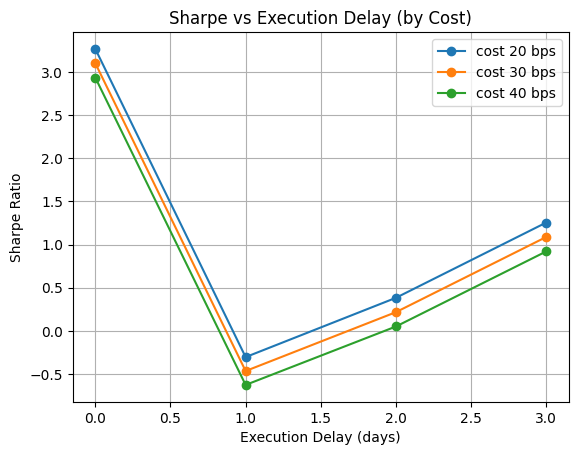



count    155.000000
mean       0.002754
std        0.047463
min       -0.111803
25%       -0.019485
50%        0.002686
75%        0.027145
max        0.216053
Name: net_pnl, dtype: float64


In [168]:
pivot_sharpe = stress_grid.pivot(
    index="delay",
    columns="cost_bps",
    values="sharpe"
)

plt.figure()

for col in pivot_sharpe.columns:
    plt.plot(pivot_sharpe.index, pivot_sharpe[col], marker='o', label=f"cost {col} bps")

plt.xlabel("Execution Delay (days)")
plt.ylabel("Sharpe Ratio")
plt.title("Sharpe vs Execution Delay (by Cost)")

plt.legend()
plt.grid()

plt.show()

print("\n")

print(daily_net.describe())

### 15. Persist the Output files

In [169]:
fp = BACKTEST_DIR / "trade_df.pkl"
trade_df.to_pickle(fp)
assert fp.exists(), "trade_df.pkl not written"
assert fp.stat().st_size > 0, "trade_df.pkl is empty"
manifest[stage_label]["trade_df"] = str(fp.relative_to(OUTPUT_ROOT))
print("saved:", fp)

fp = BACKTEST_DIR / "daily_returns.pkl"
daily_returns.to_pickle(fp)
assert fp.exists(), "daily_returns.pkl not written"
assert fp.stat().st_size > 0, "daily_returns.pkl is empty"
manifest[stage_label]["daily_returns"] = str(fp.relative_to(OUTPUT_ROOT))
print("saved:", fp)

fp = BACKTEST_DIR / "equity_curve.pkl"
equity_curve.to_pickle(fp)
assert fp.exists(), "equity_curve.pkl not written"
assert fp.stat().st_size > 0, "equity_curve.pkl is empty"
manifest[stage_label]["equity_curve"] = str(fp.relative_to(OUTPUT_ROOT))
print("saved:", fp)

fp = BACKTEST_DIR / "performance_summary.pkl"
performance_summary.to_pickle(fp)
assert fp.exists(), "performance_summary.pkl not written"
assert fp.stat().st_size > 0, "performance_summary.pkl is empty"
manifest[stage_label]["performance_summary"] = str(fp.relative_to(OUTPUT_ROOT))
print("saved:", fp)

fp = BACKTEST_DIR / "grid_results.pkl"
results_df = pd.DataFrame(results_pos)
results_df.to_pickle(fp)
assert fp.exists(), "grid_results.pkl not written"
assert fp.stat().st_size > 0, "grid_results.pkl is empty"
manifest[stage_label]["grid_results"] = str(fp.relative_to(OUTPUT_ROOT))
print("saved:", fp)


saved: ../output/005_backtest/trade_df.pkl
saved: ../output/005_backtest/daily_returns.pkl
saved: ../output/005_backtest/equity_curve.pkl
saved: ../output/005_backtest/performance_summary.pkl
saved: ../output/005_backtest/grid_results.pkl


### 999. Persist the manifest file

In [170]:
manifest[stage_label]["timestamp"] = datetime.now(UTC).isoformat()
pd.to_pickle(manifest, MANIFEST_FILE)
print("manifest saved:", MANIFEST_FILE)
print("pipeline stages:", sorted(manifest.keys()))
print(f"artifacts in {stage_label}:", sorted(manifest[stage_label].keys()))

manifest saved: ../output/manifest.pkl
pipeline stages: ['001_download', '002_enrich', '003_analysis', '004_strategy', '005_backtest']
artifacts in 005_backtest: ['daily_returns', 'equity_curve', 'grid_results', 'performance_summary', 'timestamp', 'trade_df']
